In [1]:
import sys
!{sys.executable} -m pip install matplotlib

In [2]:
%pip install osmnx networkx
%pip install plotly -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os

# Vamos testar o caminho passo a passo para ver onde o Colab se perde
pastas_para_testar = [
    "/content/drive/MyDrive/UFRN",
    "/content/drive/MyDrive/UFRN/26.1",
    "/content/drive/MyDrive/UFRN/26.1/ED2",
    "/content/drive/MyDrive/UFRN/26.1/ED2/U2"
]

print("Iniciando o raio-x do caminho...\n")

for p in pastas_para_testar:
    if os.path.exists(p):
        print(f"✅ OK: {p}")
        # Se for a última pasta da lista, mostra o que tem dentro dela
        if p == pastas_para_testar[-1]:
            print("\nPastas que o Colab está enxergando dentro de 'U2':")
            print(os.listdir(p))
    else:
        print(f"\n❌ PAROU AQUI: O Colab NÃO encontrou: {p}")
        break

In [3]:
import osmnx as ox      # Responsável por se conectar ao OpenStreetMap, baixar os dados reais da malha viária e extrair as coordenadas geográficas (latitude/longitude).
import networkx as nx   # Responsável por toda a "matemática" do projeto: cria a estrutura de dados do grafo e calcula as métricas exigidas (grau, hubs, betweenness e k-core).
import plotly.graph_objects as go
import matplotlib.pyplot as plt


In [33]:
# CÉLULA 2: DOWNLOAD DA MALHA VIÁRIA E PREPARAÇÃO
place = "Capim Macio, Natal, Rio Grande do Norte, Brazil"

# Baixando o grafo focado apenas em vias para veículos
print("Baixando o grafo. Isso pode levar alguns segundos...")
G = ox.graph_from_place(place, network_type="drive")

# Convertendo para grafo não-direcionado simples (Garante compatibilidade com o k-core)
# Usando a conversão nativa do NetworkX para evitar erros de versão do OSMnx
G_undirected = nx.Graph(G)

print(f"Grafo extraído com sucesso!")
print(f"Total de Nós (pontos): {G_undirected.number_of_nodes()}")
print(f"Total de Arestas (ruas): {G_undirected.number_of_edges()}")

Baixando o grafo. Isso pode levar alguns segundos...
Grafo extraído com sucesso!
Total de Nós (pontos): 639
Total de Arestas (ruas): 997


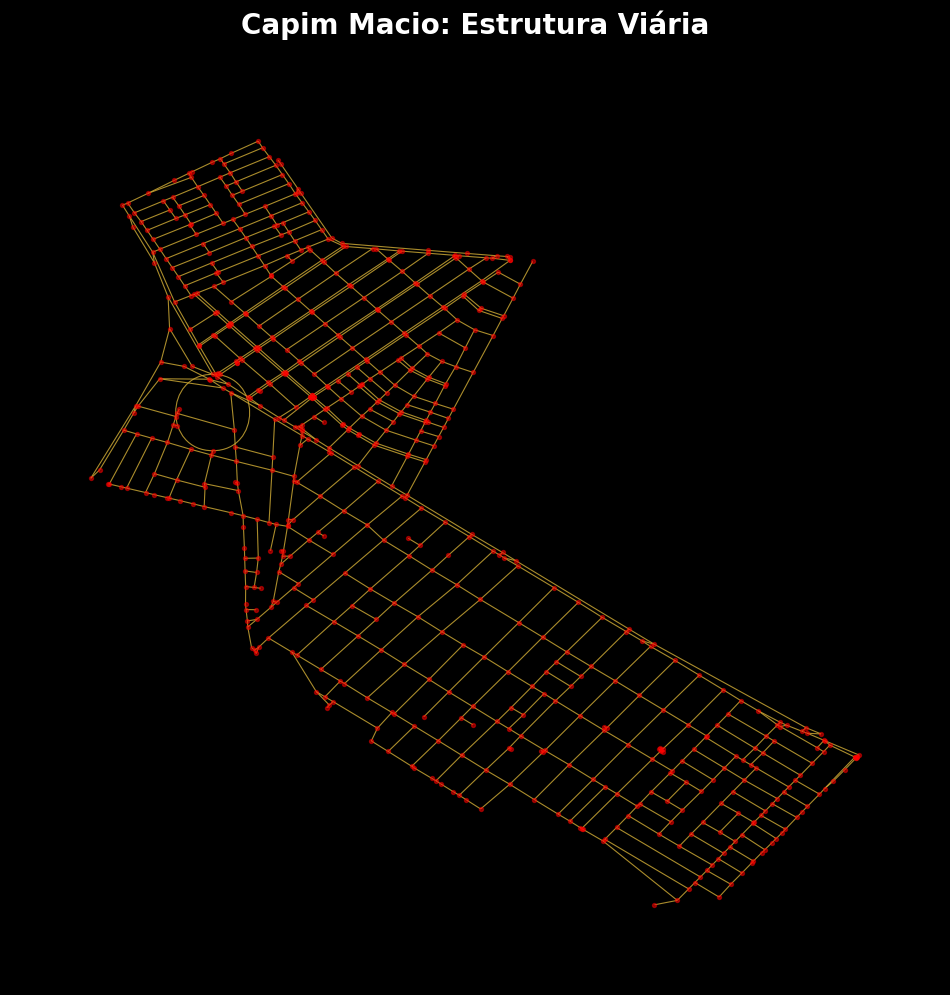

In [35]:
# Extraindo as posições dos nós para o layout geográfico
pos = {node: (data['x'], data['y']) for node, data in G_undirected.nodes(data=True)}

# 2. Configurar a figura
fig, ax = plt.subplots(figsize=(12, 12))
fig.set_facecolor("#000000")  # Cor de fundo suave
ax.set_facecolor("#000000")  # Cor de fundo suave

# 3. Desenhar as arestas (ruas)
nx.draw_networkx_edges(
    G_undirected, 
    pos, 
    ax=ax, 
    edge_color='#D4AF37',  # Código Hex para Dourado (Gold)
    width=0.8, 
    alpha=0.8,             # Leve transparência para dar sofisticação
    arrows=False
)

# 4. Desenhar os nós (pontos/interseções) - Opcional
# Aqui deixamos pequenos para não poluir
nx.draw_networkx_nodes(
    G_undirected, 
    pos, 
    ax=ax, 
    node_size=8,           # Tamanho pequeno para não esconder as ruas
    alpha=0.5,
    node_color='#FF0000'   # Vermelho Puro
)

# 5. Ajustes estéticos finais
ax.set_title("Capim Macio: Estrutura Viária", color='white', fontsize=20, fontweight='bold', pad=20)
ax.set_axis_off()          # Remove as bordas e números dos eixos

# 6. Salvar em alta definição
plt.savefig("mapa_custom.png", dpi=300, bbox_inches='tight', facecolor='black')
plt.show()